In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
piplisting = pd.read_parquet(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.parquet")
pd.set_option("display.max_columns", None)
piplisting.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,price_per_guest,price_per_bedroom,host_experience_years,host_type,luxury_flag,overall_avg_review_score,long_stay_flag
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,True,False,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,26.5,53.0,14.3,individual,Standard,22.857143,Short stay
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,True,True,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,60.0,120.0,12.3,individual,Standard,22.857143,Short stay
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,True,False,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,44.5,89.0,11.6,individual,Standard,22.857143,Short stay
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,True,True,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,29.0,58.0,12.2,individual,Standard,22.857143,Short stay
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,True,False,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,30.0,60.0,11.2,individual,Standard,22.857143,Short stay


In [3]:
total_listings = piplisting.shape[0]
print("Total Listings: ",total_listings)

Total Listings:  248278


In [4]:
avg_price = piplisting["price"].mean()
print("Average Price: ",round(avg_price, 2))

Average Price:  232.82


In [5]:
avg_review_score = piplisting["overall_avg_review_score"].mean()
int(avg_review_score)
print("Average Price: ",round(avg_price, 2))

Average Price:  232.82


In [6]:
luxury_ratio = (piplisting["luxury_flag"] == "Luxury").mean()*100
luxury_ratio
print(f"Luxury Listings: {round(luxury_ratio, 2)}%")

Luxury Listings: 24.24%


In [7]:
long_stay_ratio = (piplisting["long_stay_flag"] == "Long stay").mean()*100
long_stay_ratio
print(f"Long Stay Listings: {round(long_stay_ratio, 2)}%")

Long Stay Listings: 21.16%


In [8]:
professional_host_ratio = (piplisting["host_type"] == "professional").mean()*100
professional_host_ratio
print(f"Professional Host Listings: {round(professional_host_ratio, 2)}%")

Professional Host Listings: 25.19%


In [9]:
piplisting["host_type"].value_counts()

host_type
individual      185746
professional     62532
Name: count, dtype: int64

<h1 style="color: darkred;">Insight 1 — Price Distribution</h1>

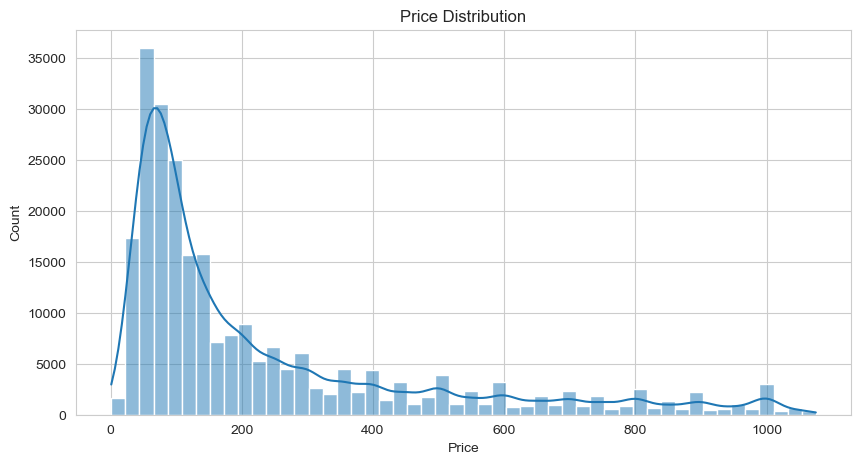

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(piplisting["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

<Axes: xlabel='price'>

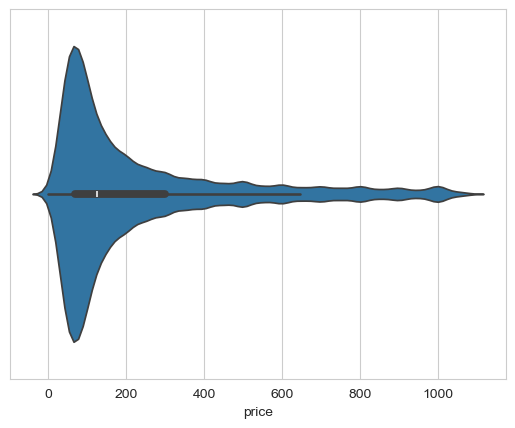

In [11]:
sns.violinplot(x = piplisting["price"])

<h3>Key insight</h3>
Most Airbnb listings are affordable or mid-range, typically priced below around $200. A smaller portion of listings fall into higher price brackets, indicating a premium or luxury segment of the market.

<h3>Business interpretation</h3>
This suggests the Airbnb marketplace is largely driven by budget-friendly and mid-range accommodations, while luxury listings represent a niche offering for higher-end travelers.

<h1 style="color:darkred">Insight 2 — Host Type Distribution</h1>

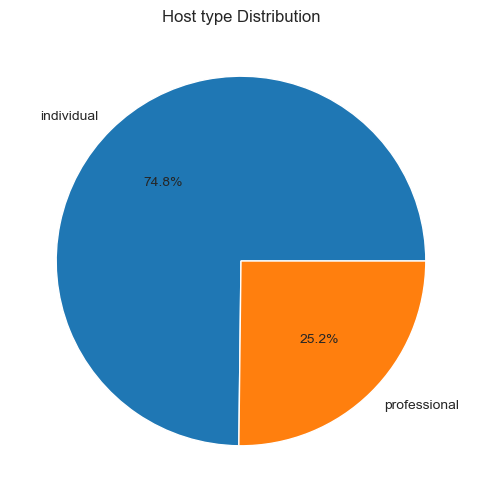

In [12]:
host_counts = piplisting["host_type"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(host_counts, labels=host_counts.index, autopct="%1.1f%%")
plt.title("Host type Distribution")
plt.show()

<h3>Key insight</h3>
The Airbnb ecosystem is predominantly composed of individual property owners, although a significant portion of listings are managed by professional hosts operating multiple properties.

<h3>Business interpretation</h3>

This reflects Airbnb’s original peer-to-peer sharing model, while also highlighting the growth of professional property management within the platform.

<h1 style="color:darkred">Insight 3 — Price vs Host Type</h1>

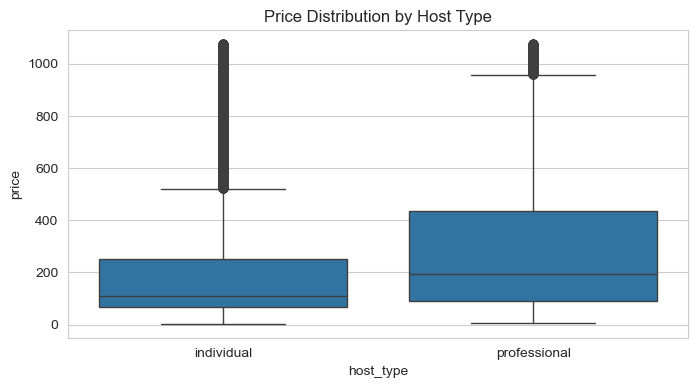

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x="host_type",y="price", data=piplisting)
plt.title("Price Distribution by Host Type")
plt.show()

<Axes: xlabel='host_type', ylabel='price'>

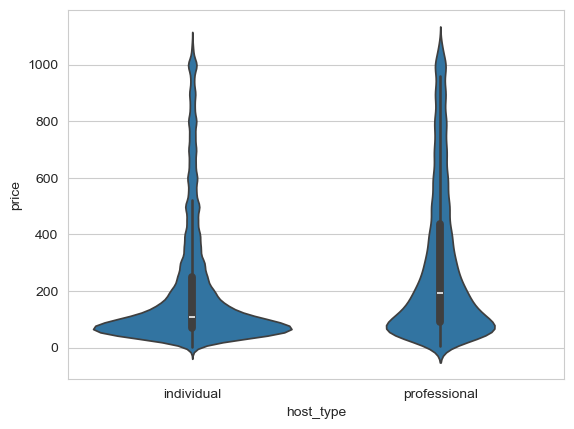

In [22]:
sns.violinplot(data=piplisting, x="host_type", y="price")

<h3>Key insight</h3>

Listings managed by professional hosts are generally priced higher and show greater price variability.

<h3>Business interpretation</h3>

Professional hosts likely manage higher-end or multiple properties, allowing them to offer both mid-range and premium accommodations.

<h1 style="color:darkred;">Insight 4 — Luxury vs Standard Listings</h1>

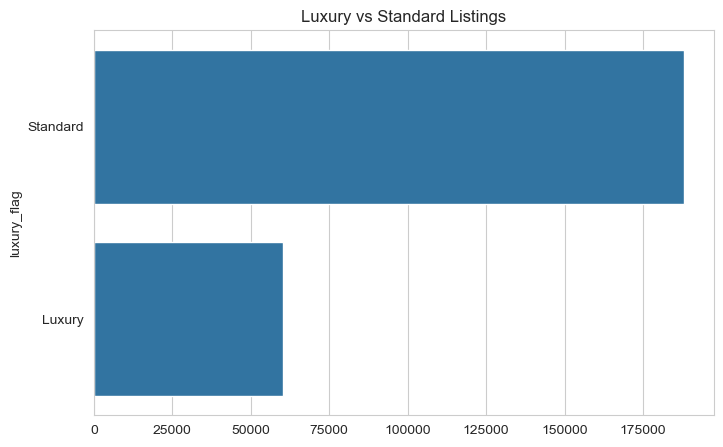

In [24]:
lux_counts = piplisting["luxury_flag"].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(y=lux_counts.index, x=lux_counts.values)
plt.title("Luxury vs Standard Listings")
plt.show()

<h3>Key insight</h3>

Only a limited portion of listings fall into the luxury category, indicating that most properties cater to mass-market travelers rather than premium segments.

<h3>Business interpretation</h3>

This suggests the platform focuses heavily on affordable travel options, while luxury listings serve a niche market of high-end guests.

<h1 style="color:darkred;" >Insight 5 — Review Score Distribution</h1>

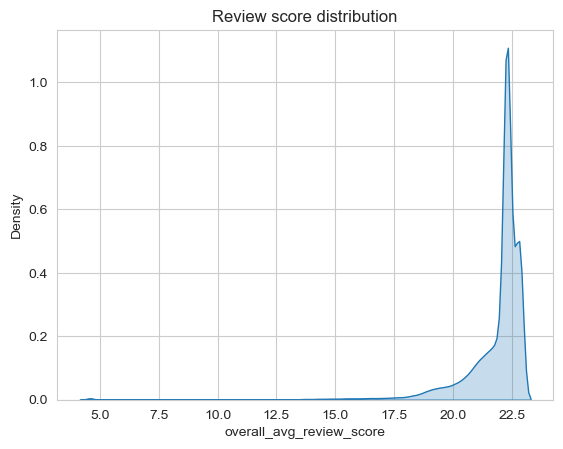

In [26]:
sns.kdeplot(piplisting["overall_avg_review_score"], fill=True)
plt.title("Review score distribution")
plt.show()

<h3>Key insight</h3>

Most listings maintain very strong guest satisfaction scores, with only a small number receiving lower ratings.

<h3>Business interpretation</h3>

This suggests that Airbnb hosts generally provide positive guest experiences, maintaining high service quality across the platform.

<h1 style="color:darkred;">Insight 6 — Long Stay vs Short Stay</h1>

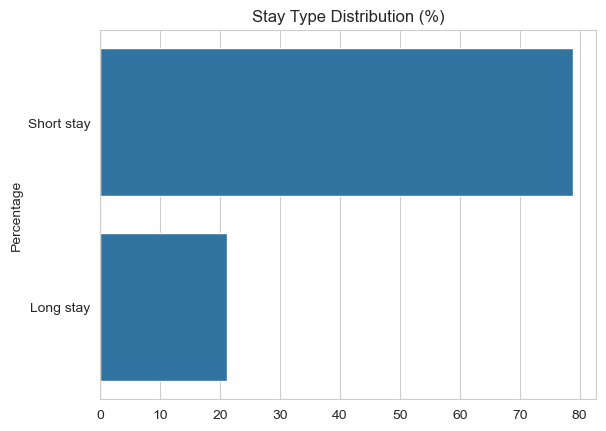

In [30]:
stay_counts = piplisting["long_stay_flag"].value_counts(normalize=True)*100
sns.barplot(x=stay_counts.values, y=stay_counts.index)
plt.title("Stay Type Distribution (%)")
plt.ylabel("Percentage")
plt.show()

<h3>Key insight</h3>

Short-term accommodations dominate the platform, reflecting Airbnb’s core focus on temporary travel and tourism stays.

<h3>Business interpretation</h3>

Long-stay listings likely target remote workers, business travelers, or extended vacations, representing a smaller but growing segment.

<h1 style="color:darkred;">Insight 7 — Price Per Guest</h1>

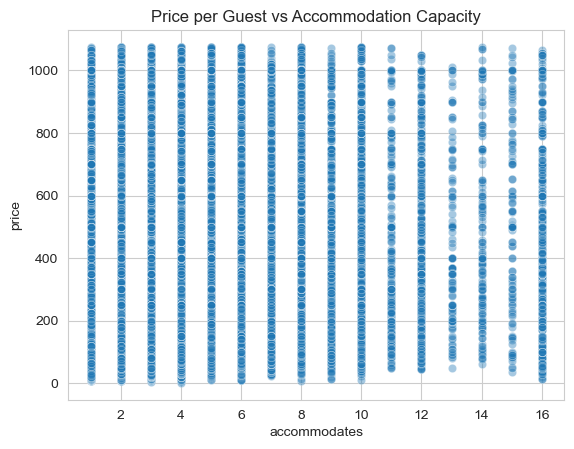

In [31]:
sns.scatterplot(x="accommodates", y="price", data=piplisting, alpha=0.4)
plt.title("Price per Guest vs Accommodation Capacity")
plt.show()

<h3>Key insight</h3>

Larger properties tend to command higher overall prices, though price variation suggests that other factors such as location, amenities, and property type also play a significant role.

<h3>Business interpretation</h3>

Guests traveling in groups may benefit from economies of scale, where the cost per guest decreases as the number of accommodated guests increases.

<h1 style="color:darkred;">Insight 8 — Host Experience Distribution</h1>

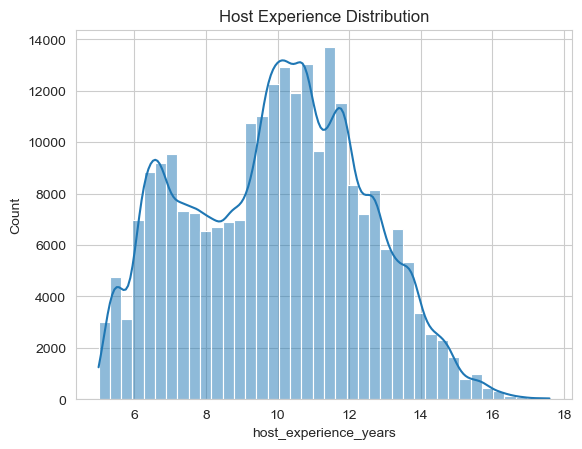

In [32]:
sns.histplot(piplisting["host_experience_years"], bins=40, kde=True)
plt.title("Host Experience Distribution")
plt.show()

<Axes: xlabel='host_experience_years', ylabel='Proportion'>

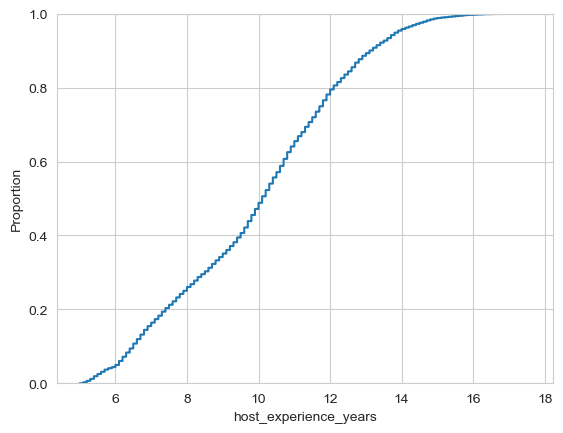

In [34]:
sns.ecdfplot(piplisting["host_experience_years"])

<h3>Key Insight</h3>

Most Airbnb hosts on the platform have moderate to high hosting experience, indicating that the marketplace is dominated by relatively experienced property managers rather than new hosts.

<h3>Business Interpretation</h3>

This suggests a mature hosting ecosystem, where experienced hosts likely maintain higher service standards and better operational efficiency.

<h1 style="color:darkred;">Insight 9 — Price per Bedroom Distribution</h1>

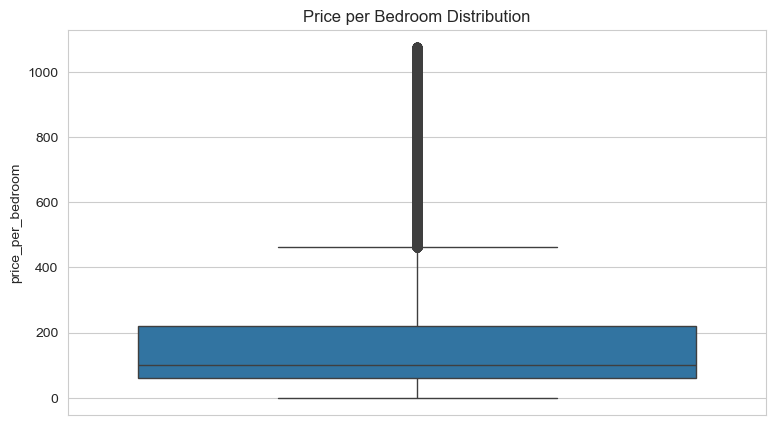

In [36]:
plt.figure(figsize=(9,5))
sns.boxplot(data=piplisting, y="price_per_bedroom")
plt.title("Price per Bedroom Distribution")
plt.show()

<h3>Key Insight</h3>

The majority of properties maintain moderate bedroom pricing, but a few premium listings significantly increase the upper range of the distribution.

<h3>Business Interpretation</h3>

Higher price-per-bedroom values likely represent luxury accommodations, premium locations, or boutique properties targeting high-end travelers.

<h1 style="color:darkred;">Insight 10 — Price vs Review Score</h1>

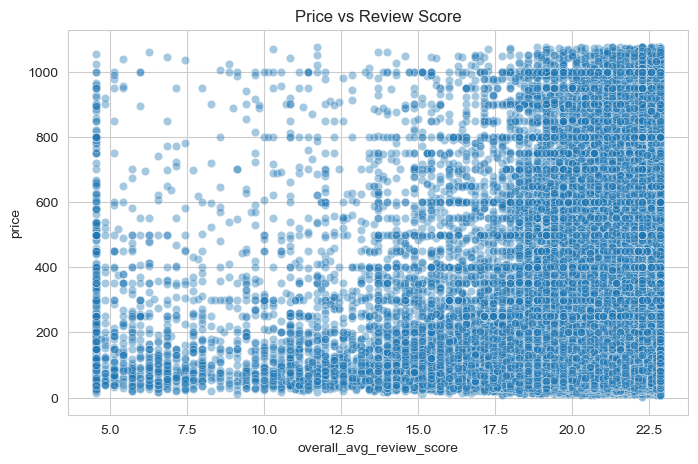

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=piplisting, x="overall_avg_review_score", y="price", alpha=0.4)
plt.title("Price vs Review Score")
plt.show()


<h3>Key Insight</h3>

Higher prices do not necessarily guarantee better reviews, suggesting that guest satisfaction depends more on experience quality, service, and amenities rather than just pricing.

<h3>Business Interpretation</h3>

Affordable listings can compete effectively with premium listings if they deliver strong customer experiences.

<h1 style="color:darkred;">Insight 11 — Luxury Listings vs Review Score</h1>

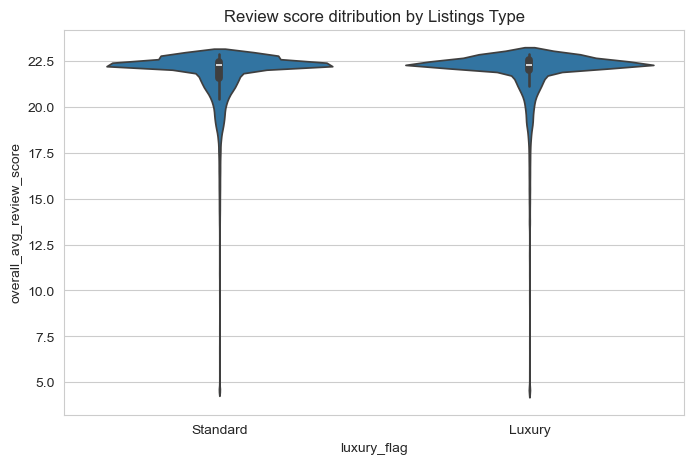

In [39]:
plt.figure(figsize=(8,5))
sns.violinplot(data=piplisting, x="luxury_flag", y="overall_avg_review_score")
plt.title("Review score ditribution by Listings Type")
plt.show()

<h3>Key Insight</h3>

Luxury listings do not significantly outperform standard listings in review scores, indicating comparable guest satisfaction levels.

<h3>Business Interpretation</h3>

Even standard listings can achieve high ratings when hosts provide good service and clean accommodations.

<h1 style="color:darkred;">Insight 12 — Host Experience vs Price</h1>

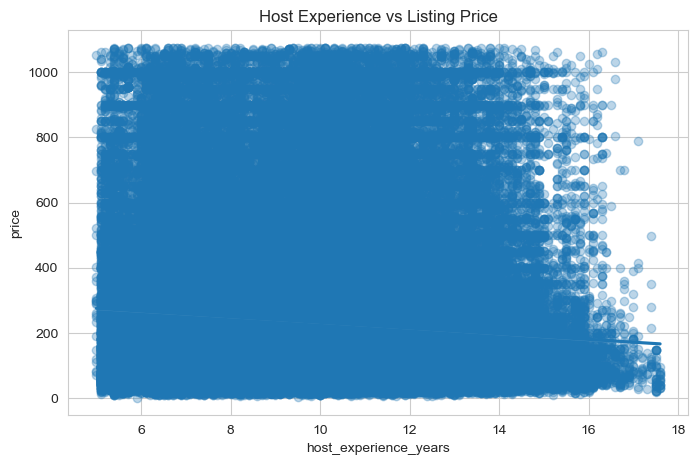

In [44]:
plt.figure(figsize=(8,5))
sns.regplot(data=piplisting, x="host_experience_years", y="price", scatter_kws={"alpha":0.3})
plt.title("Host Experience vs Listing Price")
plt.show()

<h3>Key Insight</h3>

New hosts can still compete effectively with experienced hosts by offering competitive pricing and quality accommodations.Experienced hosts do not necessarily charge higher prices, meaning pricing is influenced more by location, property type, and amenities rather than hosting tenure.

<h3>Business Interpretation</h3>

New hosts can still compete effectively with experienced hosts by offering competitive pricing and quality accommodations.

<h1 style="color:darkred">Insight 13 — Price per Guest by Room Type</h1>

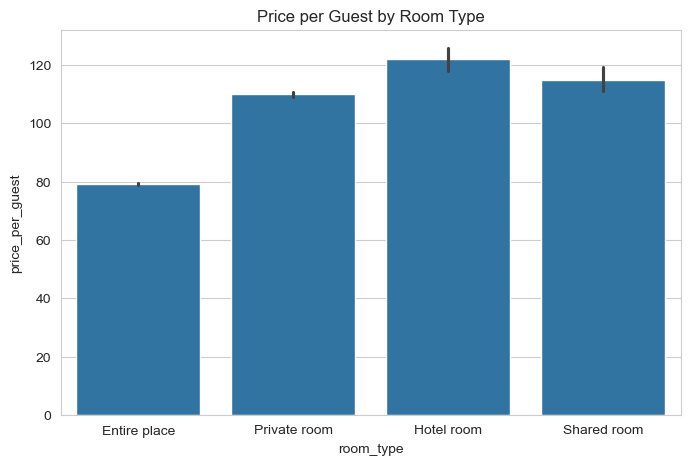

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(data=piplisting, x="room_type", y="price_per_guest")
plt.title("Price per Guest by Room Type")
plt.show()

<h3>Key Insight</h3>

Entire properties distribute costs across more guests, making them more economical per person compared to private or hotel-style accommodations.

<h3>Business Interpretation</h3>

Groups traveling together may find entire properties more cost-efficient, while solo travelers may prefer private or hotel-style rooms.

<h1 style="color:darkred;">Insight 14 — Stay Type vs Average Price</h1>

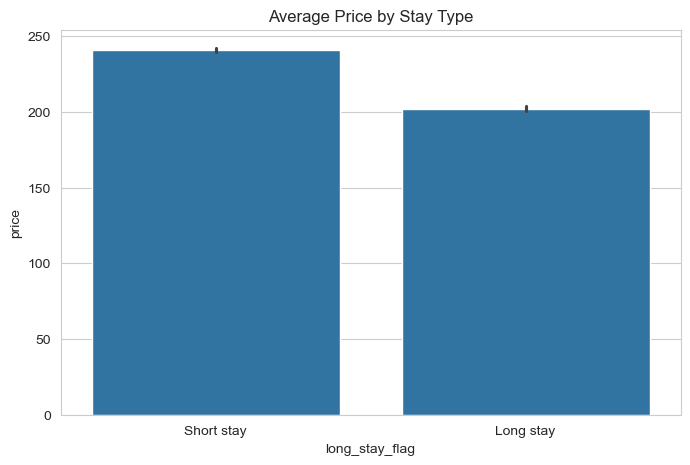

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(data=piplisting, x="long_stay_flag", y="price")
plt.title("Average Price by Stay Type")
plt.show()

<h3>Key Insight</h3>

Hosts tend to offer discounts for longer stays, lowering the average price per night.

<h3>Business Interpretation</h3>

This pricing strategy encourages extended bookings, improving occupancy stability and reducing frequent guest turnover.

<h1 style="color:blue;">Final Summary</h1>
<p style="font-weight:600; font-size:20px;">The Airbnb marketplace is largely driven by affordable listings managed primarily by individual hosts. Most hosts possess moderate experience levels, and listings generally maintain high review scores. Pricing varies significantly based on accommodation capacity, room type, and stay duration, while guest satisfaction appears largely independent of listing price.</p>

In [3]:
piplisting.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'price_per_guest', 'price_per_bedroom', 'host_experience_years',
       'host_type', 'luxury_flag', 'overall_avg_review_score',
       'long_stay_flag'],
      dtype='str')

In [6]:
piplisting["host_is_superhost"].value_counts()

host_is_superhost
False    204879
True      43399
Name: count, dtype: Int64